In [1]:
from compiler import ConstraintCompiler
from dataset import category_value_map
from omegaconf import OmegaConf


cfg = OmegaConf.load(f"config/evo-mining.yaml")


# hotfix
category_value_map = {
    k.replace("class", "label"): v for k, v in category_value_map.items()
}


attribute_index_map = {
    k.replace("class", "label"): v for v, k in enumerate(cfg.attributes)
}

compiler = ConstraintCompiler(
    attribute_index_map, category_value_map=category_value_map
)

In [2]:
import pandas as pd

dfs = []

for i in range(100):
    df = pd.read_csv(
        f"/run/media/ki/data/mln-ood/mining/gtsrb/sweeps/pareto-fitness-auroc/seed-sweep-1/stats-{i:05d}.csv"
    )
    dfs.append(df)

In [3]:
df = pd.concat(dfs)

In [4]:
df = df.groupby(by="signature").first()

In [5]:
df.shape

(313788, 9)

In [6]:
df.reset_index(inplace=True)

In [7]:
instances = df.signature.apply(lambda x: x.split(";"))

In [8]:
instances[0]

['((color=blue -> color=blue) -> (color=blue or shape=circle))',
 '((label=speed_limit_120 -> color=yellow) or shape=triangle)',
 '(not shape=inverse_triangle xor label=give_way)',
 '(shape=octagon xor label=stop)',
 'label=priority_at_next_intersection',
 'label=roundabout',
 'label=speed_limit_30',
 'label=speed_limit_80']

In [9]:
import torch

domain = [range(43), [0, 1, 2, 3], [0, 1, 2, 3, 4], [0, 1]]

# log.info(f"State space size: {prod([len(d) for d in domain]) * 4 / 1024 / 1024}MB")
state_space = torch.cartesian_prod(*[torch.tensor(d) for d in domain])

In [10]:
def compile_constraints(constraints):
    # Prepare the global namespace with torch and index constants
    global_namespace = {
        "torch": torch,
    }
    # Create a dedicated namespace dictionary
    namespace = {}
    for constraint in constraints:
        constraint = str(constraint)
        # input_constraint = "male -> not makeup"
        constraint_name = "_" + constraint.replace(" ", "_").replace(
            "->", "implies"
        ).replace("(", "").replace(")", "").replace("=", "_eq_")

        generated_code = compiler.compile(constraint_name, constraint)

        # Execute the generated code within this namespace
        exec(generated_code, global_namespace, namespace)
    rules = list(namespace.values())
    return rules

In [11]:
from tqdm.auto import tqdm

embeds = []

for individual in tqdm(instances):
    rules = compile_constraints(individual)

    with torch.no_grad():
        e = torch.zeros(size=(state_space.shape[0], 1), device="cpu")

        for i, f in enumerate(rules):
            fx = f(state_space)
            e += fx

        embedding = (e == len(rules)).long()[:, 0]
        embeds.append(embedding)

  0%|          | 0/313788 [00:00<?, ?it/s]

In [12]:
z = torch.stack(embeds).numpy()

In [13]:
(z == 0).sum()

522400572

In [14]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

# Convert embeddings to numpy array
z = torch.stack(embeds).numpy()

# Apply PCA to reduce dimensions to 200
pca = PCA(n_components=200, random_state=42)
z_pca = pca.fit_transform(z)

(array([294754.,   2872.,   5400.,    920.,   1149.,   1191.,    965.,
          1956.,   1358.,   3223.]),
 array([   0.,  172.,  344.,  516.,  688.,  860., 1032., 1204., 1376.,
        1548., 1720.]),
 <BarContainer object of 10 artists>)

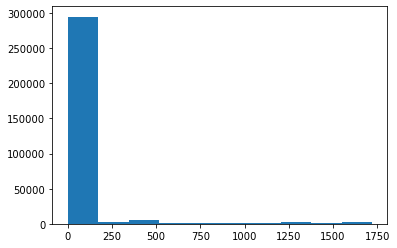

In [15]:
z = torch.stack(embeds)

plt.hist(z.sum(dim=1).numpy())

In [16]:
%%time

# Apply t-SNE
tsne = TSNE(n_components=2, perplexity=500, random_state=42, n_jobs=-1)
reduced_embeddings = tsne.fit_transform(z_pca)

CPU times: user 3h 8min 29s, sys: 10min 19s, total: 3h 18min 49s
Wall time: 1h 27min 51s


In [54]:
# data = {
#     "embeddings": reduced_embeddings,
#     "dataframe": df
# }
#
# torch.save(data, "/home/ki/evo-algo-gtsrb-loss-landscape-prob.pt")


data = torch.load("/home/ki/evo-algo-gtsrb-loss-landscape-prob.pt", weights_only=False)
reduced_embeddings = data["embeddings"]
df = data["dataframe"]

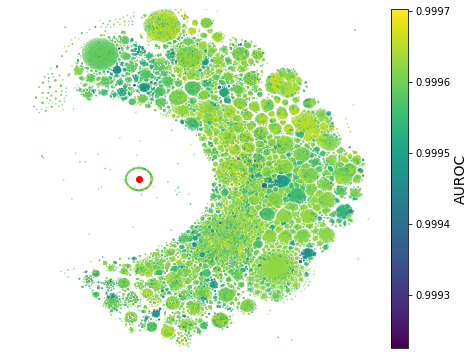

In [60]:
import matplotlib.pyplot as plt


data = torch.load("/home/ki/evo-algo-gtsrb-loss-landscape-prob.pt", weights_only=False)
reduced_embeddings = data["embeddings"]
df = data["dataframe"]

fig, ax = plt.subplots(figsize=(7, 5))

m = df[df.auroc == df.auroc.max()].index

# Scatter plot with colormap
sc = ax.scatter(
    reduced_embeddings[:, 0], reduced_embeddings[:, 1], c=df.auroc, s=2.0, marker="."
)
cbar = plt.colorbar(sc, ax=ax)

sc.set_alpha(0.6)

# Highlight max AUROC points
ax.scatter(reduced_embeddings[m, 0], reduced_embeddings[m, 1], c="red")

# Adjust colorbar
cbar.set_label("AUROC", fontsize=14)
cbar.ax.set_position([0.82, 0.2, 0.03, 0.6])  # Adjust position: [x, y, width, height]

# Remove plot borders
for spine in ax.spines.values():
    spine.set_visible(False)

# Remove ticks
ax.set_xticks([])
ax.set_yticks([])

# Set plot limits
ax.set_xlim([-150, 220])
ax.set_ylim([-200, 200])


# ax.set_xlim([-125, 100])
# ax.set_ylim([-115, 125])

plt.tight_layout()
plt.savefig("/home/ki/embed-prob.png", dpi=300, bbox_inches="tight", pad_inches=0.1)
plt.show()

In [30]:
df.auroc.min()

0.9992249369621276